
# 02 labor market risk prediction


In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Pretty print helpers
def clf_report(y_true, y_prob, thresh=0.5):
    y_pred = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    error_rate = (fp + fn) / len(y_true)
    precision_pos = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    return {
        "confusion_matrix": cm,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "error_rate": error_rate,
        "precision_predicted_positive": precision_pos
    }

def plot_roc(y_true, y_prob, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {auc_val:.3f}')
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.tight_layout()
    return auc_val


## 1. Load and Inspect Data

In [2]:

# Load the provided dataset
df = pd.read_csv('/mnt/data/Data-Audit.csv')

# Basic info
display(df.head())
df.info()
df.describe(include='all').T


,Sector_score,PARA_A,Risk_A,PARA_B,Risk_B,Money_Value,Risk_D,Score,Inherent_Risk,Audit_Risk,Risk
0,3.89,4.18,2.508,2.50,0.500,3.38,0.676,2.4,8.574,1.7148,1
1,3.89,0.00,0.000,4.83,0.966,0.94,0.188,2.0,2.554,0.5108,0
2,3.89,0.51,0.102,0.23,0.046,0.00,0.000,2.0,1.548,0.3096,0
3,3.89,0.00,0.000,10.80,6.480,11.75,7.050,4.4,17.530,3.5060,1
4,3.89,0.00,0.000,0.08,0.016,0.00,0.000,2.0,1.416,0.2832,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sector_score   776 non-null    float64
 1   PARA_A         776 non-null    float64
 2   Risk_A         776 non-null    float64
 3   PARA_B         776 non-null    float64
 4   Risk_B         776 non-null    float64
 5   Money_Value    775 non-null    float64
 6   Risk_D         776 non-null    float64
 7   Score          776 non-null    float64
 8   Inherent_Risk  776 non-null    float64
 9   Audit_Risk     776 non-null    float64
 10  Risk           776 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 66.8 KB


,count,mean,std,min,25%,50%,75%,max
Sector_score,776.0,20.184536,24.319017,1.85,2.3700,3.8900,55.5700,59.8500
PARA_A,776.0,2.450194,5.678870,0.00,0.2100,0.8750,2.4800,85.0000
Risk_A,776.0,1.351029,3.440447,0.00,0.0420,0.1750,1.4880,51.0000
PARA_B,776.0,10.799988,50.083624,0.00,0.0000,0.4050,4.1600,1264.6300
Risk_B,776.0,6.334008,30.072845,0.00,0.0000,0.0810,1.8405,758.7780
Money_Value,775.0,14.137631,66.606519,0.00,0.0000,0.0900,5.5950,935.0300
Risk_D,776.0,8.265434,39.970849,0.00,0.0000,0.0180,2.2350,561.0180
Score,776.0,2.702577,0.858923,2.00,2.0000,2.4000,3.2500,5.2000
Inherent_Risk,776.0,17.680612,54.740244,1.40,1.5835,2.2140,10.6635,801.2620
Audit_Risk,776.0,7.168158,38.667494,0.28,0.3167,0.5556,3.2499,961.5144


## 2. Clean Data & Define Features/Target

In [3]:

# Drop rows with any missing values
df_clean = df.dropna().copy()

# Outcome and predictors
y = df_clean['Risk'].astype(int)

# Use ALL other columns as predictors (per prompt)
X = df_clean.drop(columns=['Risk'])

# Keep a list of numeric columns only for models that require it
# (KNN and OLS both can use numeric input. If there are non-numeric cols, get_dummies.)
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    X = pd.get_dummies(X, drop_first=True)

X.columns = [str(c) for c in X.columns]  # ensure valid names for statsmodels

X.shape, y.shape, non_numeric[:5]


((775, 10), (775,), [])

### 3. Train/Validation Split (50/50, random_state=13)

In [4]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, random_state=13, stratify=y
)

X_train.shape, X_val.shape, y_train.mean(), y_val.mean()


((387, 10), (388, 10), 0.39276485788113696, 0.3943298969072165)


## Linear Probability Model (LPM) on Training, Evaluate on Validation

We fit OLS with `Risk` (0/1) as the dependent variable and **all** predictors.  
We then evaluate on the validation set:
- Confusion matrices at thresholds **0.5** and **0.6**
- Error rate (overall misclassification rate)
- Precision among predicted positives
- ROC Curve & AUC


In [5]:

# Add constant for statsmodels OLS
X_train_c = sm.add_constant(X_train, has_constant='add')
X_val_c = sm.add_constant(X_val, has_constant='add')

lpm = sm.OLS(y_train, X_train_c).fit()
print(lpm.summary())


                            OLS Regression Results                            
Dep. Variable:                   Risk   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                     77.28
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           7.32e-85
Time:                        02:35:42   Log-Likelihood:                -55.652
No. Observations:                 387   AIC:                             133.3
Df Residuals:                     376   BIC:                             176.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.7877      0.079     -9.917

In [6]:

# Predicted probabilities on validation
y_val_prob_lpm = lpm.predict(X_val_c).clip(0,1)

# Threshold 0.5
rep_05 = clf_report(y_val, y_val_prob_lpm, 0.5)
rep_06 = clf_report(y_val, y_val_prob_lpm, 0.6)

print("=== LPM @ 0.5 ===")
print("Confusion matrix:\n", rep_05['confusion_matrix'])
print(f"Error rate: {rep_05['error_rate']:.3f}")
print(f"Precision among predicted positives: {rep_05['precision_predicted_positive']:.3f}")

print("\n=== LPM @ 0.6 ===")
print("Confusion matrix:\n", rep_06['confusion_matrix'])
print(f"Error rate: {rep_06['error_rate']:.3f}")
print(f"Precision among predicted positives: {rep_06['precision_predicted_positive']:.3f}")


=== LPM @ 0.5 ===
Confusion matrix:
 [[223  12]
 [ 35 118]]
Error rate: 0.121
Precision among predicted positives: 0.908

=== LPM @ 0.6 ===
Confusion matrix:
 [[233   2]
 [ 40 113]]
Error rate: 0.108
Precision among predicted positives: 0.983


AUC (LPM): 0.961


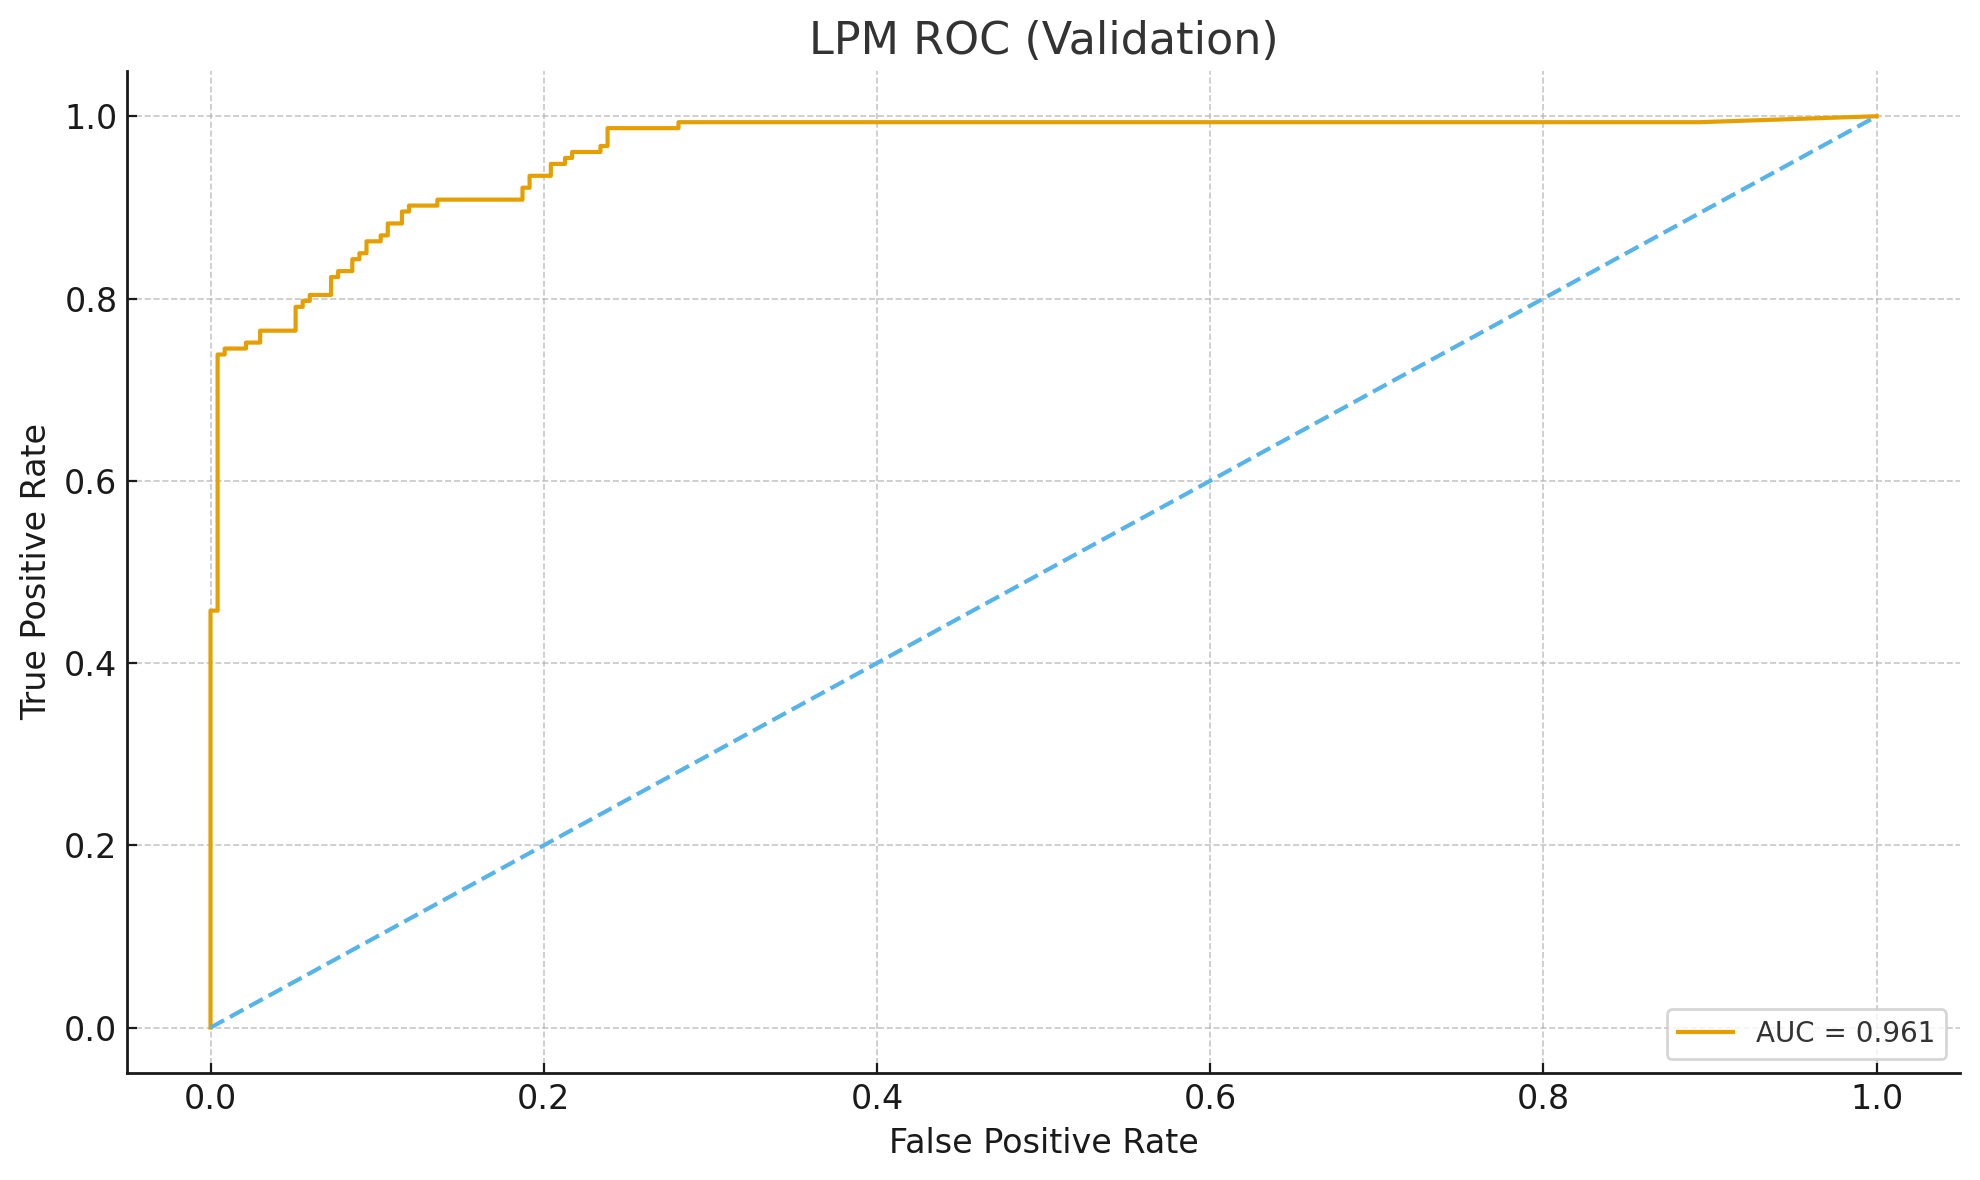

In [7]:

# ROC & AUC for LPM
auc_lpm = plot_roc(y_val, y_val_prob_lpm, title='LPM ROC (Validation)')
print(f"AUC (LPM): {auc_lpm:.3f}")


###  KNN (k=5) — Without Scaling

In [8]:

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
# We use predicted probabilities for the positive class
y_val_prob_knn5 = knn5.predict_proba(X_val)[:,1]
rep_knn5 = clf_report(y_val, y_val_prob_knn5, 0.5)

print("Confusion matrix (k=5, unscaled, thr=0.5):\n", rep_knn5['confusion_matrix'])
print(f"Error rate: {rep_knn5['error_rate']:.3f}")
print(f"Precision among predicted positives: {rep_knn5['precision_predicted_positive']:.3f}")


Confusion matrix (k=5, unscaled, thr=0.5):
 [[231   4]
 [ 15 138]]
Error rate: 0.049
Precision among predicted positives: 0.972



###  KNN (k=5) — With Standardization (Scale **Before** Split)

Following the prompt, we **standardize** each feature (mean 0, variance 1) **using the full dataset** (to reduce small‑sample noise), then split.


In [9]:

# Standardize on full X (before split) as instructed
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X)

Xtr_s, Xva_s, ytr_s, yva_s = train_test_split(
    X_scaled_full, y, test_size=0.5, random_state=13, stratify=y
)

knn5_s = KNeighborsClassifier(n_neighbors=5)
knn5_s.fit(Xtr_s, ytr_s)
yva_prob_knn5s = knn5_s.predict_proba(Xva_s)[:,1]
rep_knn5s = clf_report(yva_s, yva_prob_knn5s, 0.5)

print("Confusion matrix (k=5, scaled, thr=0.5):\n", rep_knn5s['confusion_matrix'])
print(f"Error rate: {rep_knn5s['error_rate']:.3f}")
print(f"Precision among predicted positives: {rep_knn5s['precision_predicted_positive']:.3f}")


Confusion matrix (k=5, scaled, thr=0.5):
 [[229   6]
 [  9 144]]
Error rate: 0.039
Precision among predicted positives: 0.960


###  5‑Fold Cross‑Validation to Select k (Full Dataset)

,k,cv_error
0,1,0.020645
1,2,0.033548
2,3,0.033548
3,4,0.036129
4,5,0.034839
5,6,0.036129
6,7,0.034839
7,8,0.040000
8,9,0.037419
9,10,0.038710


Best k by 5-fold CV: k=1 with error 0.021


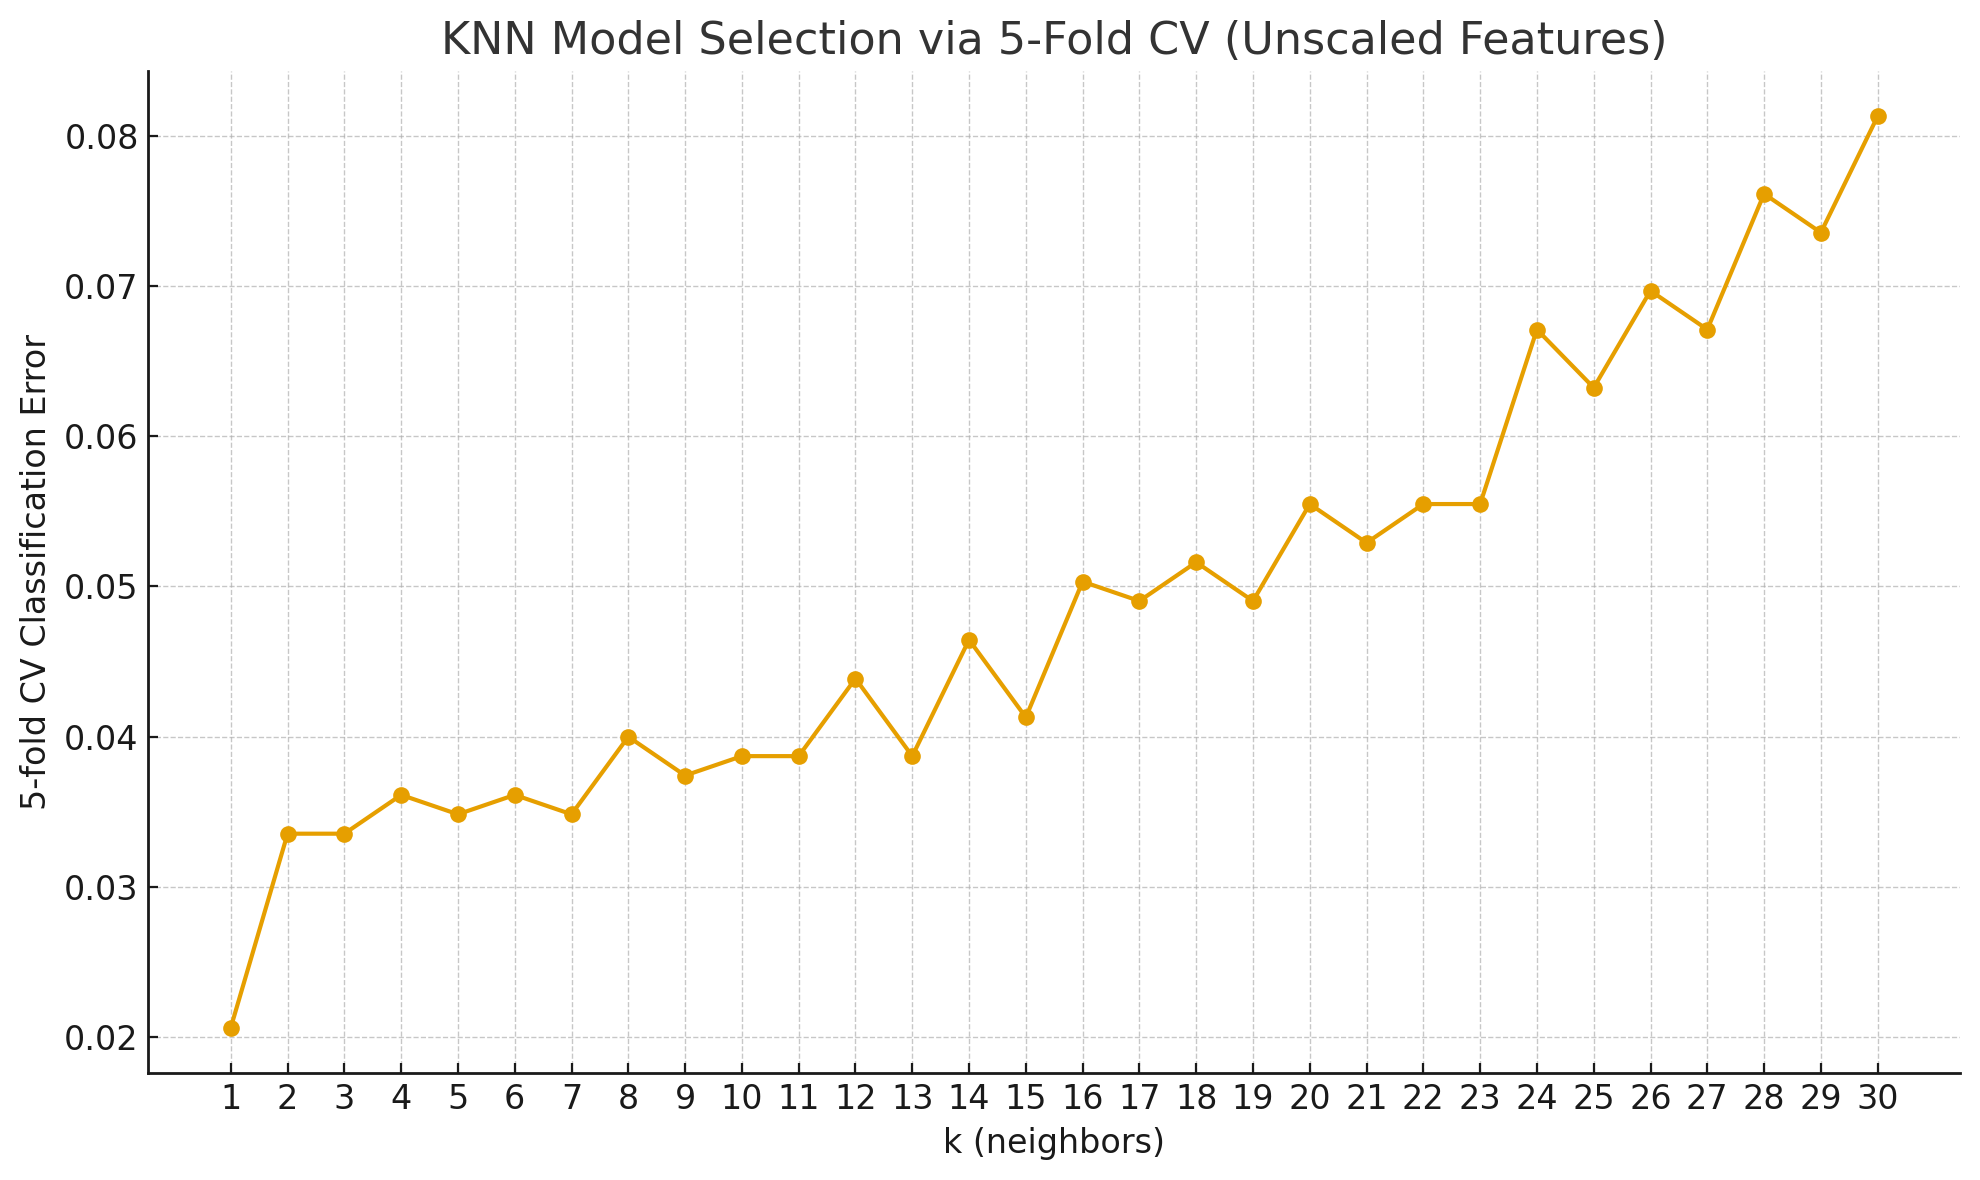

In [10]:

# Grid of k to try
k_grid = list(range(1, 31))

# Use full dataset; shuffle folds with random_state=13
cv = KFold(n_splits=5, shuffle=True, random_state=13)

# For comparability with the prompt, we DO NOT normalize here.
errs = []
for k in k_grid:
    knn = KNeighborsClassifier(n_neighbors=k)
    # cross_val_score with scoring='accuracy' returns accuracy; error = 1-accuracy
    accs = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
    errs.append(1 - accs.mean())

cv_results = pd.DataFrame({'k': k_grid, 'cv_error': errs})
best_idx = cv_results['cv_error'].idxmin()
best_k = int(cv_results.loc[best_idx, 'k'])
best_err = float(cv_results.loc[best_idx, 'cv_error'])

display(cv_results.head(10))
print(f"Best k by 5-fold CV: k={best_k} with error {best_err:.3f}")

# Simple plot
plt.figure()
plt.plot(cv_results['k'], cv_results['cv_error'], marker='o')
plt.xlabel('k (neighbors)')
plt.ylabel('5-fold CV Classification Error')
plt.title('KNN Model Selection via 5-Fold CV (Unscaled Features)')
plt.xticks(k_grid)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
